In [2]:
#reload
import scanpy as sc
adata = sc.read_h5ad("../results/adata_clustered.h5ad")

In [3]:
#DE: Cocaine vs Sucrose, split by sex (sexual dimorphism)

adata_male = adata[adata.obs["sex"] == "Male"].copy()
sc.tl.rank_genes_groups(adata_male, groupby="treatment", reference="Sucrose", method="wilcoxon")
male_de = sc.get.rank_genes_groups_df(adata_male, group="Cocaine")
male_sig = male_de[(male_de["logfoldchanges"].abs() > 1.0) & (male_de["pvals_adj"] < 0.05)]

adata_female = adata[adata.obs["sex"] == "Female"].copy()
sc.tl.rank_genes_groups(adata_female, groupby="treatment", reference="Sucrose", method="wilcoxon")
female_de = sc.get.rank_genes_groups_df(adata_female, group="Cocaine")
female_sig = female_de[(female_de["logfoldchanges"].abs() > 1.0) & (female_de["pvals_adj"] < 0.05)]

print(f"Significant DE genes — Males: {len(male_sig)}, Females: {len(female_sig)}")

male_sig.to_csv("../results/tables/male_DE_cocaine_vs_sucrose.csv", index=False)
female_sig.to_csv("../results/tables/female_DE_cocaine_vs_sucrose.csv", index=False)

/home/tanvir-ahmed/scproject2-drosophila-brain/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


Significant DE genes — Males: 50, Females: 46


/home/tanvir-ahmed/scproject2-drosophila-brain/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


In [4]:
import gseapy as gp

fly_libraries = gp.get_library_name(organism="fly")
print(fly_libraries)

['Allele_LoF_Phenotypes_from_FlyBase_2017', 'Allele_Phenotypes_from_FlyBase_2017', 'Anatomy_AutoRIF', 'Anatomy_AutoRIF_Predicted_zscore', 'Anatomy_GeneRIF', 'Anatomy_GeneRIF_Predicted_zscore', 'Coexpression_Predicted_GO_Biological_Process_2018', 'Coexpression_Predicted_GO_Cellular_Component_2018', 'Coexpression_Predicted_GO_Molecular_Function_2018', 'GO_Biological_Process_2018', 'GO_Biological_Process_AutoRIF', 'GO_Biological_Process_AutoRIF_Predicted_zscore', 'GO_Biological_Process_GeneRIF', 'GO_Biological_Process_GeneRIF_Predicted_zscore', 'GO_Cellular_Component_2018', 'GO_Cellular_Component_AutoRIF', 'GO_Cellular_Component_AutoRIF_Predicted_zscore', 'GO_Cellular_Component_GeneRIF', 'GO_Cellular_Component_GeneRIF_Predicted_zscore', 'GO_Molecular_Function_2018', 'GO_Molecular_Function_AutoRIF', 'GO_Molecular_Function_AutoRIF_Predicted_zscore', 'GO_Molecular_Function_GeneRIF', 'GO_Molecular_Function_GeneRIF_Predicted_zscore', 'Human_Disease_from_FlyBase_2017', 'InterPro_Domains_2019', 

In [5]:
#pathway enrichment for male

if len(male_sig) > 0:
    top_male_genes = male_sig["names"].tolist()[:150]
    enr_male = gp.enrichr(
        gene_list=top_male_genes,
        gene_sets=[fly_libraries[0]],   # or manually pick the exact GO_BP name from the printed list
        organism="fly",
        outdir=None
    )
    print(enr_male.results.head(10)[["Gene_set", "Term", "Adjusted P-value", "Genes"]])
    enr_male.results.to_csv("../results/tables/male_pathway_enrichment.csv", index=False)

                                  Gene_set                     Term  \
0  Allele_LoF_Phenotypes_from_FlyBase_2017       chemical resistant   
1  Allele_LoF_Phenotypes_from_FlyBase_2017  electrophoretic variant   
2  Allele_LoF_Phenotypes_from_FlyBase_2017                   viable   
3  Allele_LoF_Phenotypes_from_FlyBase_2017  temperature conditional   
4  Allele_LoF_Phenotypes_from_FlyBase_2017         mating defective   
5  Allele_LoF_Phenotypes_from_FlyBase_2017      GO0030016:myofibril   
6  Allele_LoF_Phenotypes_from_FlyBase_2017          sleep defective   
7  Allele_LoF_Phenotypes_from_FlyBase_2017                 hemocyte   
8  Allele_LoF_Phenotypes_from_FlyBase_2017             motor neuron   
9  Allele_LoF_Phenotypes_from_FlyBase_2017     dorsocentral bristle   

   Adjusted P-value                                             Genes  
0          0.061195                                      para;CG10527  
1          0.165169                                              Mdh1  
2 

In [6]:
#pathway enrichment for female

if len(female_sig) > 0:
    top_female_genes = female_sig["names"].tolist()[:150]
    enr_female = gp.enrichr(
        gene_list=top_female_genes,
        gene_sets=["Allele_LoF_Phenotypes_from_FlyBase_2017"],
        organism="fly",
        outdir=None
    )
    print(enr_female.results.head(10)[["Gene_set", "Term", "Adjusted P-value", "Genes"]])
    enr_female.results.to_csv("../results/tables/female_pathway_enrichment.csv", index=False)
else:
    print("No significant female DE genes found — skipping enrichment.")

                                  Gene_set                             Term  \
0  Allele_LoF_Phenotypes_from_FlyBase_2017                    rhabdomere R4   
1  Allele_LoF_Phenotypes_from_FlyBase_2017                    rhabdomere R5   
2  Allele_LoF_Phenotypes_from_FlyBase_2017                 neuroblast NB6-4   
3  Allele_LoF_Phenotypes_from_FlyBase_2017                    rhabdomere R2   
4  Allele_LoF_Phenotypes_from_FlyBase_2017                    rhabdomere R3   
5  Allele_LoF_Phenotypes_from_FlyBase_2017     ganglionic branch primordium   
6  Allele_LoF_Phenotypes_from_FlyBase_2017                 neuroblast NB7-3   
7  Allele_LoF_Phenotypes_from_FlyBase_2017  embryonic/larval proventriculus   
8  Allele_LoF_Phenotypes_from_FlyBase_2017       embryonic/larval esophagus   
9  Allele_LoF_Phenotypes_from_FlyBase_2017  abdominal ventral denticle belt   

   Adjusted P-value      Genes  
0          0.004340  mbl;ninaE  
1          0.004340  mbl;ninaE  
2          0.004340   SoxN;nkd 

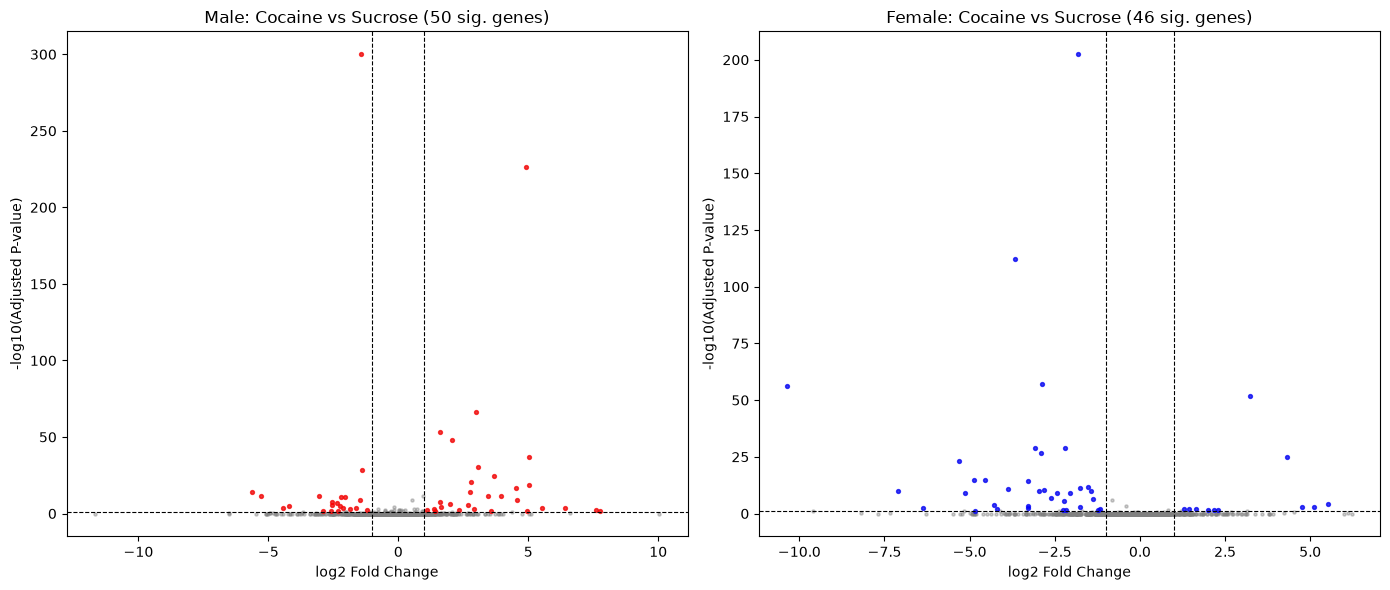

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Male volcano
axes[0].scatter(male_de["logfoldchanges"], -np.log10(male_de["pvals_adj"] + 1e-300),
                 s=5, color="gray", alpha=0.4)
axes[0].scatter(male_sig["logfoldchanges"], -np.log10(male_sig["pvals_adj"] + 1e-300),
                 s=8, color="red", alpha=0.7)
axes[0].axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=0.8)
axes[0].axvline(1.0, color="black", linestyle="--", linewidth=0.8)
axes[0].axvline(-1.0, color="black", linestyle="--", linewidth=0.8)
axes[0].set_xlabel("log2 Fold Change")
axes[0].set_ylabel("-log10(Adjusted P-value)")
axes[0].set_title(f"Male: Cocaine vs Sucrose ({len(male_sig)} sig. genes)")

# Female volcano
axes[1].scatter(female_de["logfoldchanges"], -np.log10(female_de["pvals_adj"] + 1e-300),
                 s=5, color="gray", alpha=0.4)
axes[1].scatter(female_sig["logfoldchanges"], -np.log10(female_sig["pvals_adj"] + 1e-300),
                 s=8, color="blue", alpha=0.7)
axes[1].axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=0.8)
axes[1].axvline(1.0, color="black", linestyle="--", linewidth=0.8)
axes[1].axvline(-1.0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_xlabel("log2 Fold Change")
axes[1].set_ylabel("-log10(Adjusted P-value)")
axes[1].set_title(f"Female: Cocaine vs Sucrose ({len(female_sig)} sig. genes)")

plt.tight_layout()
plt.savefig("../results/figures/fig4_volcano_male_female.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
print(f"Male significant DE genes: {len(male_sig)}")
print(f"Female significant DE genes: {len(female_sig)}")
print(f"Ratio (Male/Female): {len(male_sig) / max(len(female_sig), 1):.2f}")

Male significant DE genes: 50
Female significant DE genes: 46
Ratio (Male/Female): 1.09


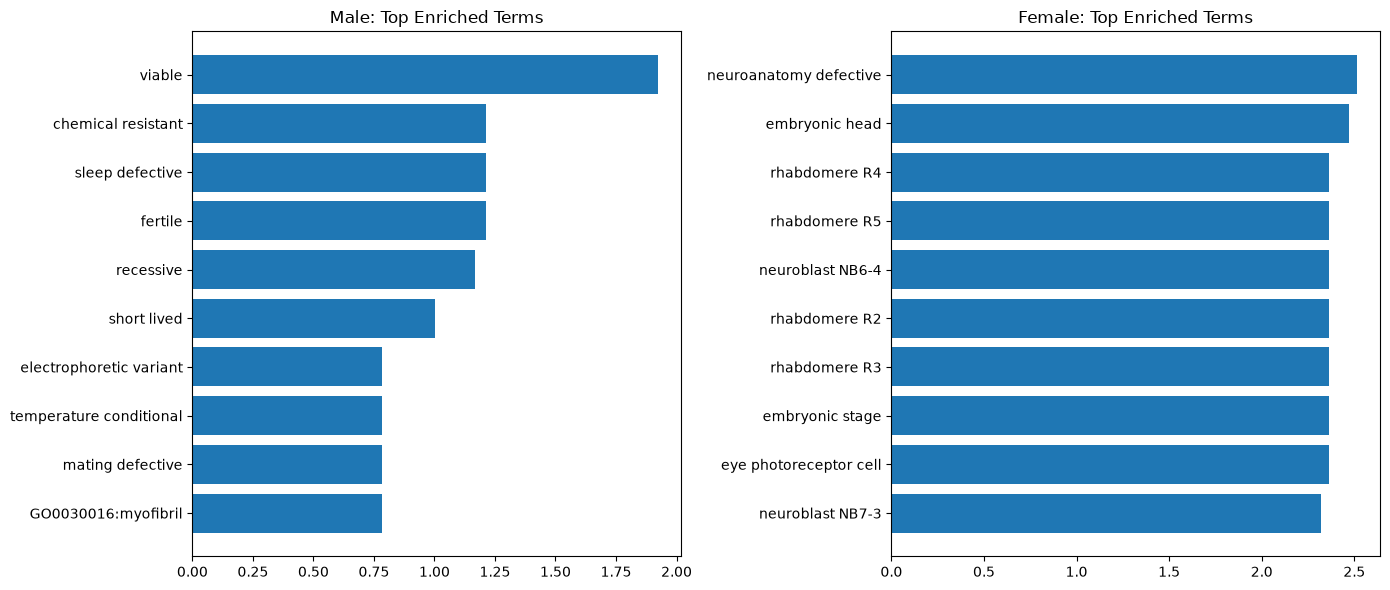

In [9]:
if len(female_sig) > 0:
    top_female_genes = female_sig["names"].tolist()[:150]
    enr_female = gp.enrichr(
        gene_list=top_female_genes,
        gene_sets=["Allele_LoF_Phenotypes_from_FlyBase_2017"],
        organism="fly",
        outdir=None
    )
    enr_female.results.to_csv("../results/tables/female_pathway_enrichment.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top10_male = enr_male.results.nsmallest(10, "Adjusted P-value")
axes[0].barh(top10_male["Term"], -np.log10(top10_male["Adjusted P-value"]))
axes[0].set_title("Male: Top Enriched Terms")
axes[0].invert_yaxis()
if len(female_sig) > 0:
    top10_female = enr_female.results.nsmallest(10, "Adjusted P-value")
    axes[1].barh(top10_female["Term"], -np.log10(top10_female["Adjusted P-value"]))
    axes[1].set_title("Female: Top Enriched Terms")
    axes[1].invert_yaxis()
plt.tight_layout()
plt.savefig("../results/figures/fig5_pathway_enrichment.png", dpi=150, bbox_inches="tight")
plt.show()